In [10]:
import mappy
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint
from FastqReader import FastQreader

from Bio import SeqIO, Seq, SeqRecord
import pysam

import nanoporePipelineCommon as npC

print(f"Imports done at {npC.get_dt(for_print=True)}")

Imports done at 07/10/23 @ 11:57:09 AM


In [3]:
# Libraries
treated_parent = Path('/data16/marcus/working/230613_nanoporeRun_sMV025-RNAStds_50-50_LT_TAD_Nano3P/output_dir')
mock_parent = Path('/data16/marcus/working/230612_nanoporeRun_sMV025-RNAStds_50-50_LT_MockTAD_Nano3P/output_dir')

treated_fastq = treated_parent / 'cat_files' / 'cat.fastq'
mock_fastq = mock_parent / 'cat_files' / 'cat.fastq'

treated_bam = treated_parent / 'cat_files' / 'cat.sorted.mappedAndPrimary.bam'
mock_bam = mock_parent / 'cat_files' / 'cat.sorted.mappedAndPrimary.bam'

# Genome
genome_parent = Path('/data16/liam/genomes/plus_cerENO2_elegansRelease100')
genome_cDNA_fasta = genome_parent / '230327_allcDNA_plus-cerENO2.cdna.all.fa'
genome_DNA_fasta = genome_parent / '230327_allChrs_plus-cerENO2.allChrs.fa'
genome_gtf = genome_parent / '230327_allChrs_plus-cerENO2.gtf'
genome_parsed_gtf = genome_parent / '230327_allChrs_plus-cerENO2.gtf.parquet'
genome_bed = genome_parent / '230327_allChrs_plus-cerENO2.bed'

In [60]:
# Alignments
alignments = '/home/liam/Polysome-Shadowing/3nt_alignments/230613.AtoG.primary.sam'
mapq_scores = []
read_ids = []
gc = {}
for read in pysam.AlignmentFile(alignments,'rb'):
    mapq_scores.append(read.mapping_quality)
    print(read.query_name)
    read_ids.append(read.query_name)

    

80e9b2ff-c60f-4ee5-8a3a-1fe807c87d3c
41d95b02-ff5a-44d4-84c7-2a0526422043
d80544cf-a1fe-4aa3-877c-6d89d913ac9c
61f05a5a-e779-4807-9722-c504befe2ffd
64ddcb50-16d0-4427-b928-89f2a2fad178
89c5a459-5093-43af-9623-615f9395d7e9
472fad8d-a3f0-4edc-8895-84bcf35ea539
d7e5cbfe-fe20-4359-8cf6-69fd659c0256
354a687c-b251-45d6-85ea-f81cbc342f08
8c5c4499-81a7-4fa6-a9f7-8fcb25a587d8
0d5448e8-8468-4311-abd6-36f27368fc9c
dd1d1ad4-d45b-4b99-97d5-1b7156a06d49
7aa971d7-69ea-43e6-a795-71f226f41345
5fe61ad9-1949-41ea-b9ea-0371f0594372
369a7764-8b3f-4939-843f-3a41fbdddbc4
bce90cf0-e3c2-4a3d-b803-41ea0d1855a9
f0793448-04d4-4420-86b6-1a16d873ed85
5e9a0af9-6187-4430-8348-25e18606e9bc
022bec38-03fb-419e-846c-3a871569869c
0aa920c7-da4e-4897-b258-568d87a597f4
1c950a08-a24a-4303-ba4c-dc516b1d8c30
f27eda5a-2339-48c1-9836-48ca79f59a7f
714cf6d0-6447-4162-991e-2078e9f4bc15
425ec29e-88ff-4f93-9e0d-5cf113d9405c
a9d887fa-0498-4c29-82ab-06a04701f80a
0f21db27-b009-4068-9f62-cb5e6edb56d3
91d1eab2-fe1f-47c8-954c-cbdd418cbb2d
a

<AxesSubplot: ylabel='Density'>

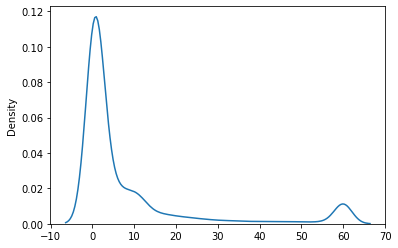

In [61]:
import seaborn as sns
sns.kdeplot(mapq_scores)

In [55]:
reads = {}
fastq = FastQreader(treated_fastq)
read_lengths_mapped = []
read_lengths_unmapped = []
gc_mapped = []
gc_unmapped = []

g_mapped = []
g_unmapped = []

a_mapped = []
a_unmapped = []

for record in fastq.readFastq():
    
    if record[0].split()[0][1:] in read_ids:
        read_lengths_mapped.append(len(record[1]))
        gc_mapped.append((record[1].upper().count('G') + record[1].upper().count('C')) / len(record[1]))
        g_mapped.append(record[1].upper().count('G')/len(record[1]))
        a_mapped.append(record[1].upper().count('A')/len(record[1]))
    else:
        gc_unmapped.append((record[1].upper().count('G') + record[1].upper().count('C')) / len(record[1]))
        g_unmapped.append(record[1].upper().count('G')/len(record[1]))
        a_unmapped.append(record[1].upper().count('A')/len(record[1]))
        read_lengths_unmapped.append(len(record[1]))
        


        


<AxesSubplot: ylabel='Count'>

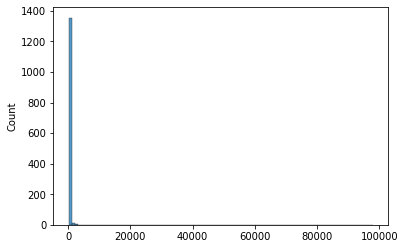

In [52]:
sns.histplot(read_lengths_mapped, bins=100)



<AxesSubplot: ylabel='Count'>

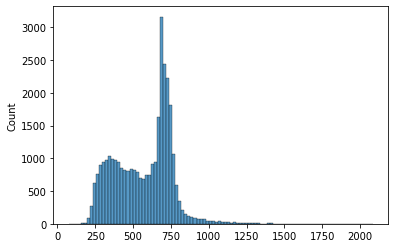

In [49]:
sns.histplot(read_lengths_unmapped, bins=100)

<AxesSubplot: ylabel='Density'>

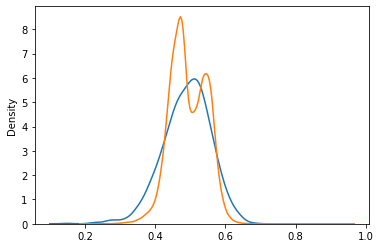

In [39]:
sns.kdeplot(gc_mapped, label='Mapped')
sns.kdeplot(gc_unmapped, label='Unmapped')

<AxesSubplot: ylabel='Density'>

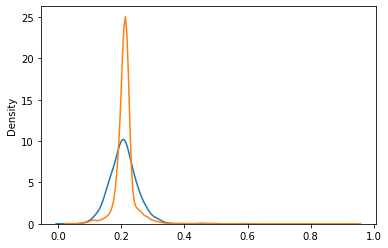

In [56]:
sns.kdeplot(g_mapped, label='Mapped')
sns.kdeplot(g_unmapped, label='Unmapped')

<AxesSubplot: ylabel='Density'>

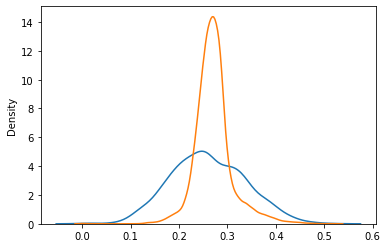

In [57]:
sns.kdeplot(a_mapped, label='Mapped')
sns.kdeplot(a_unmapped, label='Unmapped')